In [2]:
import requests
from rdflib import Graph, URIRef, Literal, Namespace
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
#VIRTUOSO_URL = "http://localhost:8890/sparql-graph-crud"
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI = "http://example.com/Gent-Terneuzen"
USERNAME = "dba"
PASSWORD = "dba"
AUTH  = (USERNAME,PASSWORD)


In [4]:
params = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

In [5]:
LIMIT = 100000 
offset = 0
g = Graph()
time_series_data = [] 
df = pd.DataFrame()

# Identifying unique sensors

In [6]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT  DISTINCT ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data = res.json()
bindings = data['results']['bindings']

for row in bindings:
    # Extract the URI string and add it to the set
    sensor_uri = row['sensor']['value']
    sensor_set.add(sensor_uri)

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)


Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289429042'}


In [7]:
# print("Fetching date-value pairs...")
# query = f"""
#     PREFIX sosa: <http://www.w3.org/ns/sosa/>
#     SELECT ?time ?value ?sensor
#     WHERE {{ 
#         GRAPH <{GRAPH_URI}> {{ 
#             ?obs a sosa:Observation ;
#                  sosa:resultTime ?time ;
#                  sosa:hasSimpleResult ?value ;
#                  sosa:madeBySensor ?sensor .
#         }} 
#     }} 
#     """
# res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})


# if res.status_code != 200:
#         print(f"Error: {res.status_code}")
#         print("Response:", res.text)
# else:
#     print("Data fetched successfully!")

# bindings = res.json()['results']['bindings']

# for row in bindings:
#     df = df.append({'time': row['time']['value'], 'value': float(row['value']['value']), 'sensor': row['sensor']['value']}, ignore_index=True)

# # df = pd.DataFrame([
# #         {'time': row['time']['value'], 'value': float(row['value']['value'])} 
# #         for row in bindings
# #     ])

# df['time'] = pd.to_datetime(df['time'])
# print("Finished!")

In [8]:


# 1. Initialize an empty DataFrame for the master table
# We will start with just the 'time' column or an empty DF
final_df = pd.DataFrame()

print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    # Use the sensor URI (or just the ID part) as the column name
    column_name = sensor_uri.split('/')[-1] 
    
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{ 
            GRAPH <{GRAPH_URI}> {{ 
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }} 
        }} 
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        
        # 2. Create a temporary DF for THIS sensor
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']), 'unixtime': int(row['unixtime']['value'])} 
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            
            # 3. Merge this sensor into the final_df
            if final_df.empty:
                final_df = temp_df
            else:
                # 'outer' join ensures we keep timestamps even if some sensors are missing data
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')

            
            print(f"Added column for sensor: {column_name}")

# 4. Final touches
final_df = final_df.sort_values('time').set_index('time')

print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289441042
Added column for sensor: 289435042
Added column for sensor: 289423042
Added column for sensor: 289429042
Finished!
                           289441042    unixtime  289435042  289423042  \
time                                                                     
2021-03-03 23:15:00+00:00    4797.72  1614813300    3606.54        NaN   
2021-03-03 23:30:00+00:00    4717.80  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    4745.36  1614815100    3556.45     902.27   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN        NaN   
2021-03-04 00:15:00+00:00        NaN  1614816900        NaN     901.96   

                           289429042  
time                                  
2021-03-03 23:15:00+00:00    1605.77  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00    1602.34  
2021-03-04 00:00:00+00:00    1611.26  
2021-03-04 00:15:00+00:00    1614.24  


# ARIMA models

## Auto correlation

# Random Forest

In [23]:
# Create a copy to avoid overwriting the original data
data = final_df.copy().sort_index()

# 1. Feature Engineering: Create Lags for ALL sensors
# This gives the model "context" of what happened 15 mins ago across the whole canal
for col in data.columns:
    data[f'{col}_lag1'] = data[col].shift(1)

# 2. Add Time Features (Periodicity)
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek

# 3. Drop rows with NaNs (created by the shift)
data.dropna(inplace=True)

# 4. Define Target (What you want to predict) and Features
# Let's predict the NEXT value of the first sensor
target_sensor = data.columns[0] # e.g., 'sensor_A'

y = data[target_sensor]
X = data.drop(columns=[target_sensor]) # Use all lags and time features to predict it


Metric          Value
----------------------
MAE          311.6628
RMSE         808.9171
R²             0.9741


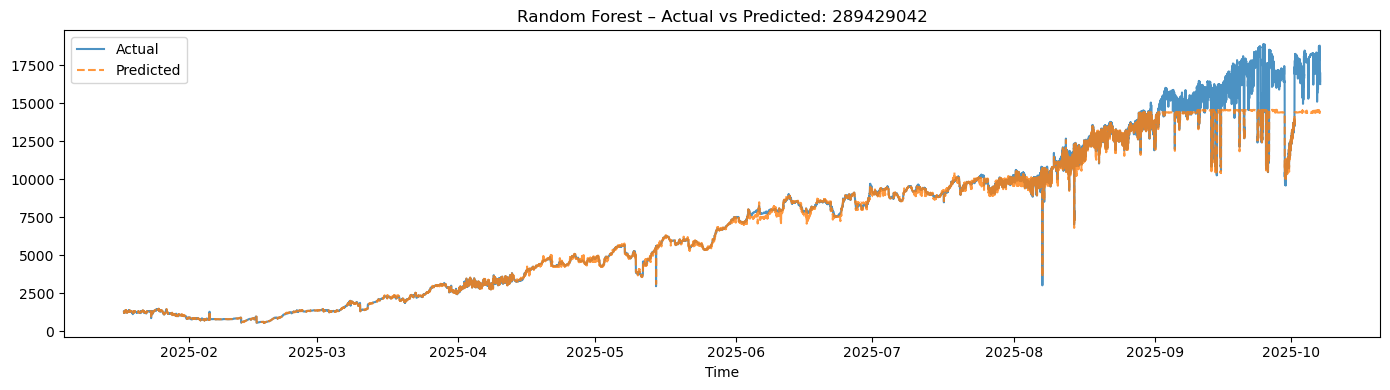

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Split at 70% mark
split_idx = int(len(data) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Initialize the Model
# n_estimators=100 is a good start; max_depth prevents overfitting
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# 3. Predict & Evaluate
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n{'Metric':<10} {'Value':>10}")
print("-" * 22)
print(f"{'MAE':<10} {mae:>10.4f}")
print(f"{'RMSE':<10} {rmse:>10.4f}")
print(f"{'R²':<10} {r2:>10.4f}")

# 4. Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test.index, y_test.values,  label='Actual',    alpha=0.8)
ax.plot(y_test.index, y_pred,          label='Predicted', alpha=0.8, linestyle='--')
ax.set_title(f'Random Forest – Actual vs Predicted: {target_sensor}')
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()

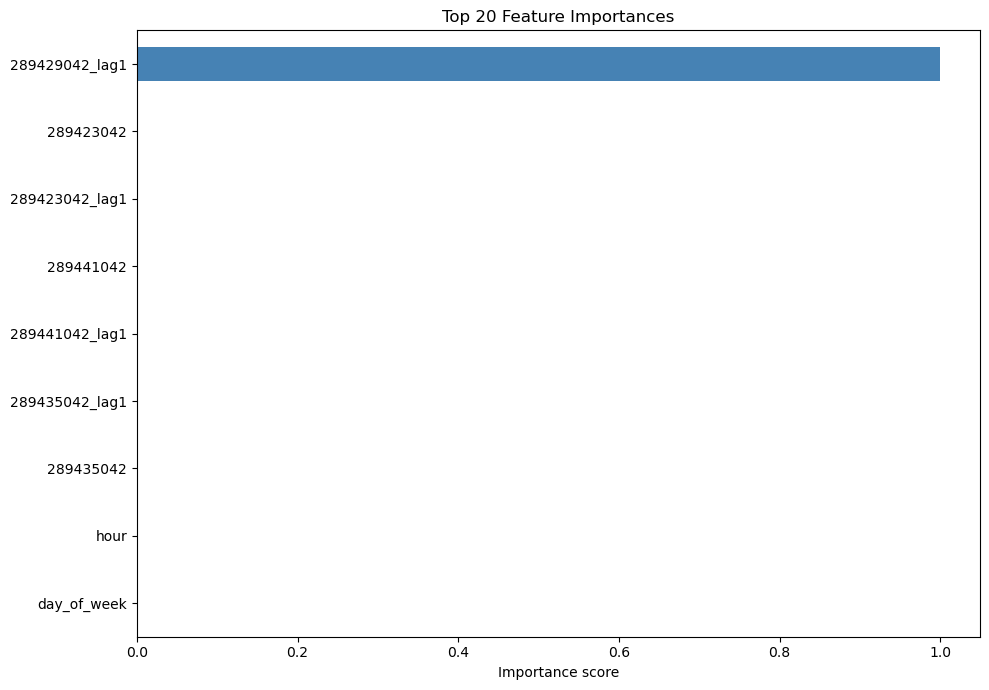

In [27]:
# ── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_n = importances.nlargest(20)   # show top 20 only — cleaner chart

fig, ax = plt.subplots(figsize=(10, 7))
top_n.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()


# Support vector regression (SVR)

In [59]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Create a copy to avoid overwriting the original data
data = final_df.copy().sort_index()
data = data.dropna()
# 1. Define your inputs (X) and what you want to predict (y)
x = data[['unixtime', '289423042', '289441042', '289435042']]
y = data['289429042'] # Predicting sensor 1 based on the others

# 2. Scale everything
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# 3. Fit the model
# We use 'rbf' for complex water patterns
model = SVR(kernel='rbf', C=10, epsilon=0.1) 
model.fit(X_scaled, y)

SVR(C=10)

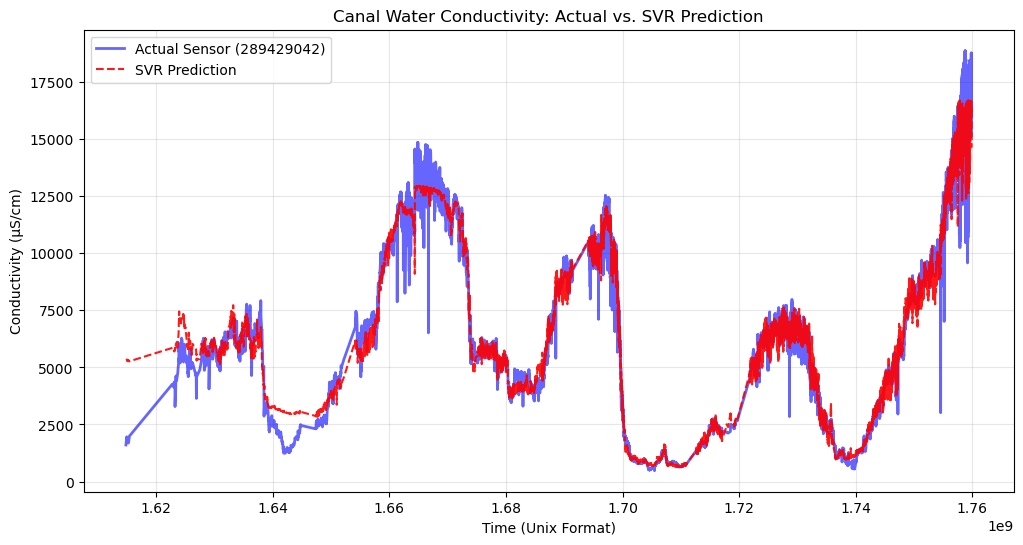

R-squared Accuracy: 0.9720


In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure the data is sorted by time for a clean line plot
data = data.sort_values('unixtime') 

# 2. Get predictions
# We use the already scaled X from your training step
y_pred = model.predict(X_scaled)

# 3. Visualization
plt.figure(figsize=(12, 6))

# Use the index if your timestamp is the index, 
# or use data['unixtime'] if you want to see the raw numbers.
# If you have a human-readable column, use that here:
time_axis = data['unixtime'] 

plt.plot(time_axis, y.values, label='Actual Sensor (289429042)', color='blue', alpha=0.6, linewidth=2)
plt.plot(time_axis, y_pred, label='SVR Prediction', color='red', linestyle='--', alpha=0.9)

plt.title('Canal Water Conductivity: Actual vs. SVR Prediction')
plt.xlabel('Time (Unix Format)')
plt.ylabel('Conductivity (µS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Quick Metric Check
from sklearn.metrics import r2_score
print(f"R-squared Accuracy: {r2_score(y, y_pred):.4f}")

In [62]:
from sklearn.metrics import r2_score, mean_squared_error

# Calculate the metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R-squared Score: {r2:.4f}")
print(f"Average Error (RMSE): {rmse:.2f} µS/cm")

R-squared Score: 0.9720
Average Error (RMSE): 656.05 µS/cm


# Gradient Boosting

## Gradient Boosting 1 sensor

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

data = final_df.copy().sort_index()

# We will focus on predicting one target sensor for the next 24 hours
target_sensor = '289429042'


# Create historical "Lag" features for the target sensor 
# use the past 2 hours of data (8 steps of 15 minutes) as memory
n_lags = 8
for lag in range(1, n_lags + 1):
    data[f'lag_{lag}'] = data[target_sensor].shift(lag)

# Add time-based features to help the model learn cyclical patterns
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month

# Drop the rows with NaN values created by the shift
data = data.dropna()

# Define our features (X) and target (y)
feature_cols = [f'lag_{i}' for i in range(1, n_lags + 1)] + ['hour', 'day_of_week', 'month']
X = data[feature_cols]
y = data[target_sensor]

# 2. Chronological Train-Test Split
# To validate a 24-hour forecast, we withhold the final 24 hours (96 steps) as our test set
forecast_steps = 96 
X_train, X_test = X.iloc[:-forecast_steps], X.iloc[-forecast_steps:]
y_train, y_test = y.iloc[:-forecast_steps], y.iloc[-forecast_steps:]

# 3. Train the Gradient Boosting Model
print("Training Gradient Boosting Regressor (this may take a moment)...")
gb_model = GradientBoostingRegressor(
    n_estimators=150, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42
)
gb_model.fit(X_train, y_train)
print("Training Complete!")

# 4. Recursive Forecasting for the next 24 hours
# We extract the very last known 2 hours of data from our training set to seed the forecast
recent_history = y_train.values[-n_lags:].tolist() 
forecasts = []
future_dates = y_test.index 

print("Generating 24-hour forecast...")
for i in range(forecast_steps):
    # Construct the lag features from our rolling history
    # [::-1] reverses the list so the most recent prediction becomes lag_1
    current_lag_features = recent_history[::-1][:n_lags]
    
    # Extract the datetime features for the exact future time we are predicting
    pred_time = future_dates[i]
    time_features = [pred_time.hour, pred_time.dayofweek, pred_time.month]
    
    # Combine lags and time features into a single row for prediction
    x_pred = pd.DataFrame([current_lag_features + time_features], columns=feature_cols)

    
    # Predict the next 15-minute step
    pred_val = gb_model.predict(x_pred)[0]
    forecasts.append(pred_val)
    
    # Append the new prediction to our history so we can use it to predict the step after that
    recent_history.append(pred_val)

Training Gradient Boosting Regressor (this may take a moment)...
Training Complete!
Generating 24-hour forecast...


In [17]:
# 5. Evaluate and Visualize
mae = mean_absolute_error(y_test, forecasts)
r2 = r2_score(y_test, forecasts)


24-Hour Forecast Accuracy:
MAE:  787.23 µS/cm
R²:   -0.1327


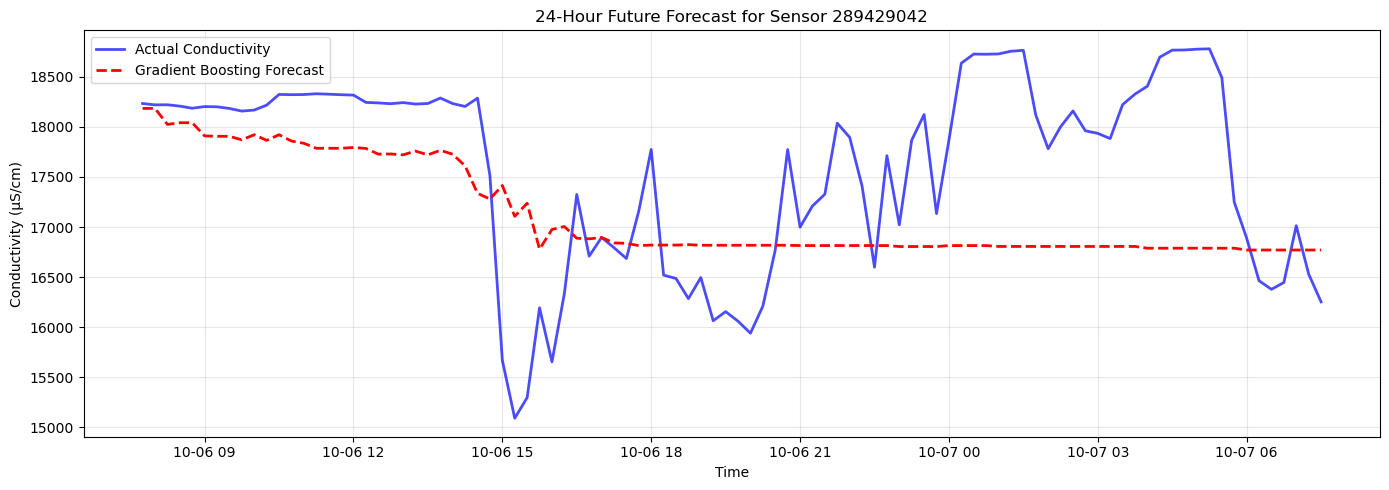

In [18]:
print(f"\n24-Hour Forecast Accuracy:")
print(f"MAE:  {mae:.2f} µS/cm")
print(f"R²:   {r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Actual Conductivity', color='blue', linewidth=2, alpha=0.7)
plt.plot(y_test.index, forecasts, label='Gradient Boosting Forecast', color='red', linestyle='--', linewidth=2)
plt.title(f'24-Hour Future Forecast for Sensor {target_sensor}')
plt.xlabel('Time')
plt.ylabel('Conductivity (µS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Gradient Boosting multiple sensors

In [19]:
# 1. Prepare the Data
data = final_df.copy().sort_index()

target_sensor = '289429042'
all_sensors = ['289429042', '289423042', '289441042', '289435042']

# Crucial Step for Multivariate Data: Fill missing values
# If one sensor drops out for 15 minutes, we don't want to discard the row.
# Forward-fill (ffill) uses the last known value, which is standard for time series.
data[all_sensors] = data[all_sensors].ffill().bfill()

n_lags = 8 # 2 hours of memory

# 2. Create Historical Lags for ALL 4 Sensors
feature_cols = []
for sensor in all_sensors:
    for lag in range(1, n_lags + 1):
        col_name = f'{sensor}_lag_{lag}'
        data[col_name] = data[sensor].shift(lag)
        feature_cols.append(col_name)

# Add time features
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month
feature_cols += ['hour', 'day_of_week', 'month']

# Drop the rows with NaNs caused by the shift
data = data.dropna()

# X contains our lags and time, y contains the current reading of ALL 4 sensors
X = data[feature_cols]
y = data[all_sensors] 

# 3. Chronological Train-Test Split (Withholding the last 24 hours / 96 steps)
forecast_steps = 96
X_train, X_test = X.iloc[:-forecast_steps], X.iloc[-forecast_steps:]
y_train, y_test = y.iloc[:-forecast_steps], y.iloc[-forecast_steps:]

# 4. Train the Multi-Output Model
# MultiOutputRegressor creates one Gradient Booster per target sensor under the hood.
print("Training Multivariate Gradient Boosting Regressor (this may take a minute)...")
base_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
multi_model = MultiOutputRegressor(base_model)

multi_model.fit(X_train, y_train)
print("Training Complete!")

# 5. The Multivariate Recursive Forecast
# We create a dictionary to hold the rolling history for each of the 4 sensors
recent_history = {sensor: y_train[sensor].values[-n_lags:].tolist() for sensor in all_sensors}

target_forecasts = []
future_dates = y_test.index 

print("Generating 24-hour multivariate forecast...")
for i in range(forecast_steps):
    
    # A. Build the feature row for this specific step
    current_features = []
    for sensor in all_sensors:
        # Get the last 8 steps for each sensor, reversing them so lag_1 is first
        current_features.extend(recent_history[sensor][::-1][:n_lags])
        
    # B. Add the time features for the exact future time we are predicting
    pred_time = future_dates[i]
    current_features.extend([pred_time.hour, pred_time.dayofweek, pred_time.month])
    
    # C. Reshape for the model
    x_pred = np.array(current_features).reshape(1, -1)
    
    # D. Predict all 4 sensors at once
    pred_vals = multi_model.predict(x_pred)[0] # Returns an array of 4 values
    
    # E. Append the new predictions to our rolling histories
    for idx, sensor in enumerate(all_sensors):
        recent_history[sensor].append(pred_vals[idx])
        
        # We only strictly care about evaluating the target sensor
        if sensor == target_sensor:
            target_forecasts.append(pred_vals[idx])

Training Multivariate Gradient Boosting Regressor (this may take a minute)...
Training Complete!
Generating 24-hour multivariate forecast...


c:\Users\AYMANS\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\AYMANS\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\AYMANS\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\AYMANS\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
c:\Users\AYMANS\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have val

In [20]:
# 6. Evaluate and Visualize
mae = mean_absolute_error(y_test[target_sensor], target_forecasts)
r2 = r2_score(y_test[target_sensor], target_forecasts)


Multivariate 24-Hour Forecast Accuracy (Sensor 289429042):
MAE:  567.04 µS/cm
R²:   0.0613


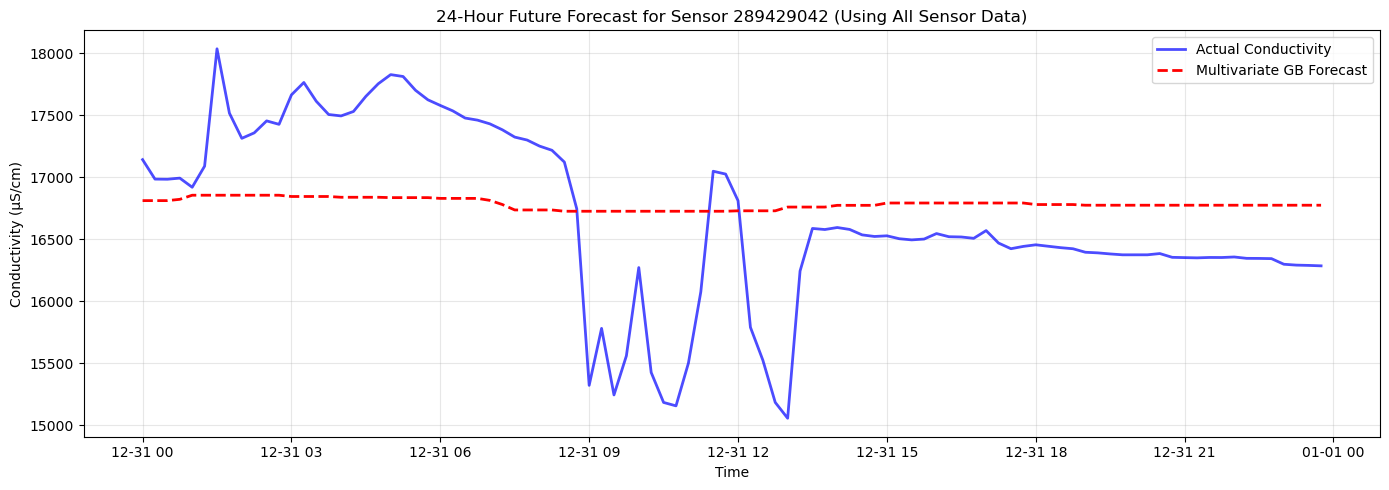

In [21]:
print(f"\nMultivariate 24-Hour Forecast Accuracy (Sensor {target_sensor}):")
print(f"MAE:  {mae:.2f} µS/cm")
print(f"R²:   {r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test[target_sensor].values, label='Actual Conductivity', color='blue', linewidth=2, alpha=0.7)
plt.plot(y_test.index, target_forecasts, label='Multivariate GB Forecast', color='red', linestyle='--', linewidth=2)
plt.title(f'24-Hour Future Forecast for Sensor {target_sensor} (Using All Sensor Data)')
plt.xlabel('Time')
plt.ylabel('Conductivity (µS/cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()